<a href="https://colab.research.google.com/github/amlucky0/AI-Driven-Citizen-Grievance-System/blob/main/1_Data_Cleaning_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np

# Synthetic Data Creation
data = {
    "ticket_id": range(101, 201),
    "raw_text": [
        "There is a major water leakage in our street since yesterday. Huge wastage of water!",
        "Street lights are not working near the main cross road. It is very dark and unsafe at night.",
        "The main road is full of potholes. Driving has become extremely dangerous.",
        "Garbage has not been collected for the past 5 days. The smell is unbearable.",
        "Frequent power cuts in our area since last week. Students cannot study for exams.",
    ] * 20, # 100 rows generate karne ke liye
    "department": ["Water", "Electricity", "Roads", "Sanitation", "Electricity"] * 20
}

df = pd.DataFrame(data)
df.to_csv("citizen_grievances.csv", index=False)
print("Dataset successfully created as 'citizen_grievances.csv'!")
print(df.head())

Dataset successfully created as 'citizen_grievances.csv'!
   ticket_id                                           raw_text   department
0        101  There is a major water leakage in our street s...        Water
1        102  Street lights are not working near the main cr...  Electricity
2        103  The main road is full of potholes. Driving has...        Roads
3        104  Garbage has not been collected for the past 5 ...   Sanitation
4        105  Frequent power cuts in our area since last wee...  Electricity


In [5]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Download NLTK resources
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    # 1. Lowercase convert karna
    text = text.lower()
    # 2. Special characters aur numbers hatana
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # 3. Tokenize, Stopwords removal aur Lemmatization
    tokens = text.split()
    cleaned_tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]

    return " ".join(cleaned_tokens)

# Apply preprocessing
df['cleaned_text'] = df['raw_text'].apply(clean_text)
print("Text cleaning complete!")
print(df[['raw_text', 'cleaned_text']].head())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


Text cleaning complete!
                                            raw_text  \
0  There is a major water leakage in our street s...   
1  Street lights are not working near the main cr...   
2  The main road is full of potholes. Driving has...   
3  Garbage has not been collected for the past 5 ...   
4  Frequent power cuts in our area since last wee...   

                                        cleaned_text  
0  major water leakage street since yesterday hug...  
1  street light working near main cross road dark...  
2  main road full pothole driving become extremel...  
3        garbage collected past day smell unbearable  
4  frequent power cut area since last week studen...  


/tmp/ipykernel_3839/3538137147.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='department', palette='viridis')


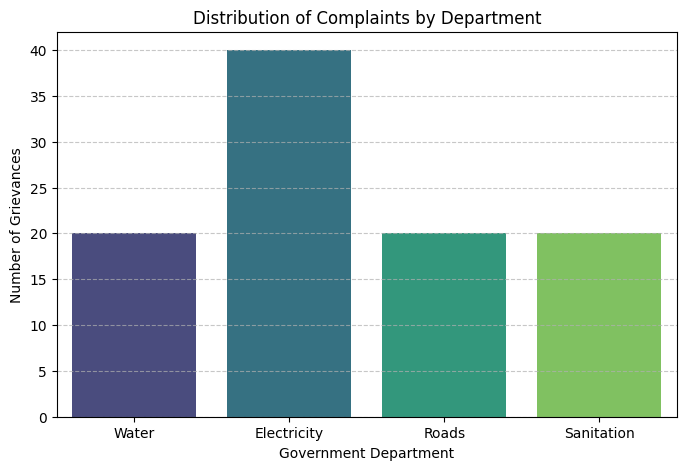

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='department', palette='viridis')
plt.title('Distribution of Complaints by Department')
plt.xlabel('Government Department')
plt.ylabel('Number of Grievances')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

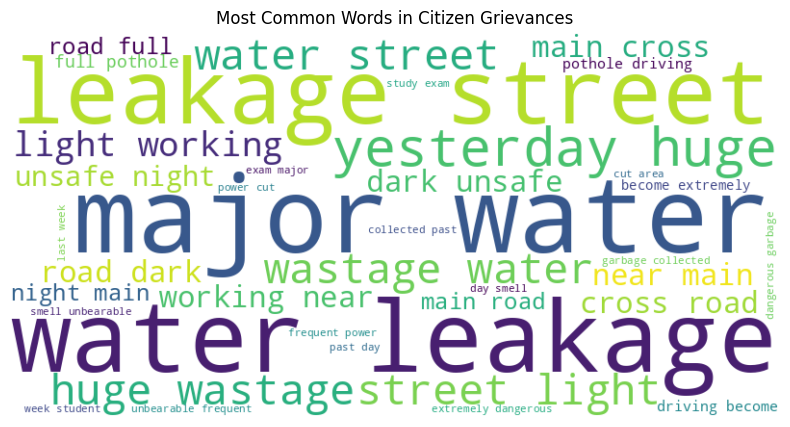

/tmp/ipykernel_3839/3255302823.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=bigram_counts.values, y=bigram_counts.index, palette='magma')


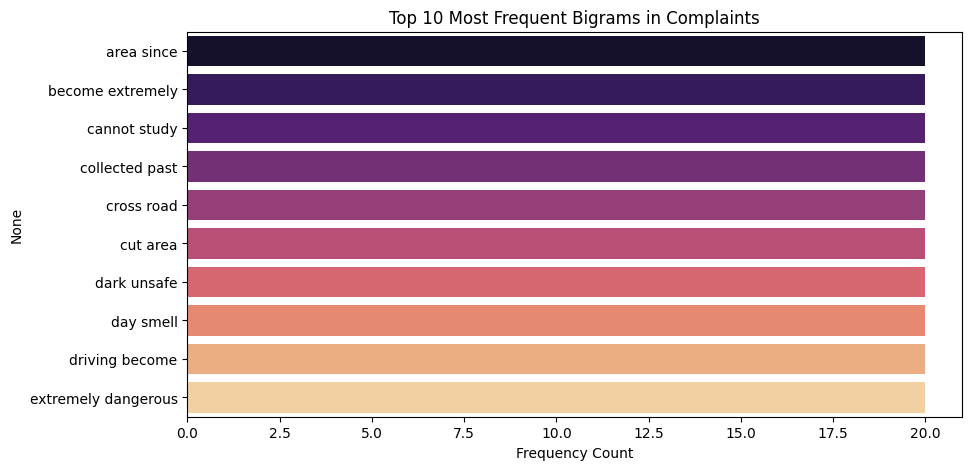

In [7]:
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer

# 1. Word Cloud Generation
all_text = " ".join(df['cleaned_text'])
wordcloud = WordCloud(width=800, height=400, background_color='white', max_words=50).generate(all_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Citizen Grievances')
plt.show()

# 2. Bigram (2-gram) Frequency Distribution
cv = CountVectorizer(ngram_range=(2, 2), max_features=10)
bigrams = cv.fit_transform(df['cleaned_text'])
bigram_counts = pd.DataFrame(bigrams.toarray(), columns=cv.get_feature_names_out()).sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=bigram_counts.values, y=bigram_counts.index, palette='magma')
plt.title('Top 10 Most Frequent Bigrams in Complaints')
plt.xlabel('Frequency Count')
plt.show()